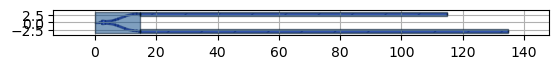

In [1]:
from siepic import all as pdk
from ipkiss3 import all as i3

# 1. Instantiate the Y-branch to act as the 50/50 beam splitter
splitter = pdk.EbeamY1550()
splitter_tt = splitter.Layout().ports["opt2"].trace_template

# 2. Define the lengths for the two reflective arms
# The delay is created by the difference in arm lengths (round-trip)
arm1_length = 100.0
arm2_length = 120.0

# 3. Use WaveguideStraight for the arms 
# In a real circuit, these would terminate in a Bragg mirror or loop mirror
wg_arm1 = pdk.WaveguideStraight(wg_length=arm1_length, trace_template=splitter_tt)
wg_arm2 = pdk.WaveguideStraight(wg_length=arm2_length, trace_template=splitter_tt)

# 4. Define the circuit specifications
# A Michelson uses one port as input/output and two ports for the arms
specs = [
    i3.Inst("yb_1", splitter),
    i3.Inst("arm_up", wg_arm1),
    i3.Inst("arm_down", wg_arm2),
    # Connect arms to the splitter
    i3.Join("yb_1:opt2", "arm_up:pin1"),
    i3.Join("yb_1:opt3", "arm_down:pin1"),
    i3.Place("yb_1:opt1", (0, 0)),
]

# 5. Expose ports
# Note: Light travels to the end of the arms and reflects back to 'opt1'
exposed_port_names = {
    "yb_1:opt1": "in_out",
    "arm_up:pin2": "reflection_point_1",
    "arm_down:pin2": "reflection_point_2",
}

michelson_circuit = i3.Circuit(
    name="michelson_interferometer",
    specs=specs,
    exposed_ports=exposed_port_names,
)

# 6. Generate Layout
michelson_layout = michelson_circuit.Layout()
michelson_layout.visualize()

In [2]:
from siepic import all as pdk
from ipkiss3 import all as i3
import numpy as np

def get_angle(straight_length, delay_length, initial_angle):
    total_length = straight_length + delay_length
    initial_angle_rad = initial_angle * np.pi / 180.0

    def f(angle_rad):
        return np.abs(angle_rad / np.sin(angle_rad) - total_length / straight_length)

    from scipy.optimize import minimize

    res = minimize(
        f,
        x0=initial_angle_rad,
        bounds=((0, np.pi / 2),),
    ).x[0]
    angle = abs(res) * 180.0 / np.pi

    return angle

class Michelson(i3.Circuit):
    
    # 2. We instantiate the waveguides we will use for the arms of the MZI.
    straight_length = i3.PositiveNumberProperty(default=200.0)
    delay_length = i3.PositiveNumberProperty(default=20.0)
    initial_angle = i3.PositiveNumberProperty(default=10.0)
    curvature_radius = i3.PositiveNumberProperty(default=5.0)

    def _default_specs(self):
        splitter = pdk.EbeamY1550()
        directional_coupler = pdk.EbeamDCTE1550()

        # variable parameters        
        straight_length = self.straight_length
        delay_length = self.delay_length
        bump_angle = get_angle(straight_length=self.straight_length, delay_length=self.delay_length, initial_angle=self.initial_angle)

        # Get the trace template from the splitter
        trace_template_splitter = splitter.Layout().ports["opt2"].trace_template
        wg_s = pdk.WaveguideSBend(radius=self.curvature_radius, trace_template=trace_template_splitter)
        wg_bend180 = pdk.WaveguideBend(radius=self.curvature_radius, angle=180.0, trace_template=trace_template_splitter)
        wg_straight = pdk.WaveguideStraight(wg_length=straight_length, trace_template=trace_template_splitter)
        wg_tip = pdk.WaveguideStraight(wg_length=straight_length/5, trace_template=trace_template_splitter)
        wg_bump = pdk.WaveguideBump(x_offset=straight_length, angle=bump_angle, trace_template=trace_template_splitter)

        # 3. We define the cells that make up our circuit. We have 2 Y-branches, one bump waveguide and one straight waveguide.
        # 4. We snap the ports to each other by using `i3.Join`.
        # Other placement specifications define all the transformations that apply to each instance.
        return [
            i3.Inst(["yb_1", "yb_2"], splitter),
            i3.Inst(["wgs_1", "wgs_2"], wg_s),
            i3.Inst("dc", directional_coupler),
            i3.Inst("wg_bend_up", wg_bend180),
            i3.Inst("wg_bend_down", wg_bend180),
            i3.Inst("wg_up", wg_bump),
            i3.Inst("wg_down", wg_straight),
            # i3.Inst("wg_tip", wg_tip),

            i3.Join("dc:opt3", "wg_up:pin1"),
            i3.Join("dc:opt4", "wg_down:pin1"),
            
            i3.Join("wg_up:pin2", "yb_1:opt1"),
            i3.Join("wg_down:pin2", "yb_2:opt1"),


            i3.Join("yb_1:opt2", "wgs_1:pin1"),
            i3.FlipH("wg_bend_up"),
            i3.Join("wgs_1:pin2", "wg_bend_up:pin1"),
            i3.FlipH("wgs_2"),
            i3.Join("yb_2:opt3", "wgs_2:pin2"),
            i3.Join("wgs_2:pin1", "wg_bend_down:pin1"),

        ]

    # 5. We define the names of the external ports that we want to access.
    def _default_exposed_ports(self):
        exposed_ports = {
                            "dc:opt1": "in",
                            "dc:opt2": "out",
        }
        return exposed_ports

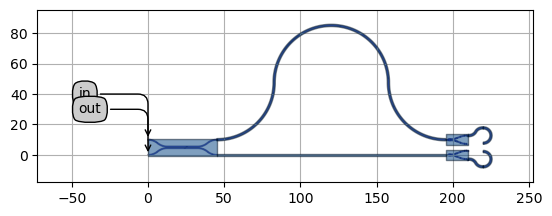

c:\Users\admin\OneDrive - UPV\EDX_140425\edx\1.5_photonic_circuit\3_design_proposal\EBeam_NicolasCasteleyn_michelson_design.gds

In [3]:
# Create the MZI with a custom delay
my_mzi = Michelson(straight_length=150.0, delay_length=100.0)

# Generate the layout
mzi_layout = my_mzi.Layout()

# Visualize
mzi_layout.visualize(annotate=True)

# Export to GDS
mzi_layout.write_gdsii("EBeam_NicolasCasteleyn_michelson_design.gds")

In [4]:
# Circuit model
my_circuit_cm = my_mzi.CircuitModel()
wavelengths = np.linspace(1.52, 1.58, 4001)
S_total = my_circuit_cm.get_smatrix(wavelengths=wavelengths)

# Plotting
S_total.visualize(
    term_pairs=[
        ("in:0", "out:0"),  # TE transmission
    ],
    scale="dB",
)

netlist_from_layout (line 222): 
Layout <class '__main__.Michelson.Layout'> has unconnected ports:
     - wg_bend_down:pin2 (<OpticalPort 'wg_bend_down:pin2': (220.078449, 2.250000), a=180.000000, D=<StripWaveguideTemplate.Layout view 'ebeam_y_1550opt2_tt:layout'>>)
     - wg_bend_up:pin2 (<OpticalPort 'wg_bend_up:pin2': (220.078449, 7.750000), a=180.000000, D=<StripWaveguideTemplate.Layout view 'ebeam_y_1550opt2_tt:layout'>>)
     - yb_1:opt3 (<OpticalPort 'yb_1:opt3': (210.078449, 7.250000), a=0.000000, D=<StripWaveguideTemplate.Layout view 'ebeam_y_1550opt3_tt:layout'>>)
     - yb_2:opt2 (<OpticalPort 'yb_2:opt2': (210.078449, 2.750000), a=0.000000, D=<StripWaveguideTemplate.Layout view 'ebeam_y_1550opt2_tt:layout'>>)


ValueError: netlist of CircuitModelView <Michelson.CircuitModel view 'PCELL_1:circuitmodel'> has unconnected terms:
[<InstanceTerm yb_1:opt3>,
 <InstanceTerm yb_2:opt2>,
 <InstanceTerm wg_bend_up:pin2>,
 <InstanceTerm wg_bend_down:pin2>]

# FP resonator

https://opg.optica.org/oe/fulltext.cfm?uri=oe-30-6-9450